# 19 &middot; Compressed Vibration Modes: trading global modes for *local* ones

**Linear modal analysis (LMA)** solves $H u = \omega^2 M u$ (stiffness $H$, mass $M$) for the shapes an
elastic body likes to vibrate in, but its low modes are **global**: on a beam they are standing waves over
the whole length, a poor basis for editing, actuating or simulating a body part by part. **Compressed
modes** ([Brandt &amp; Hildebrandt, 2017](https://www.sciencedirect.com/science/article/abs/pii/S0167839617300377))
add a mass-weighted $L_1$ penalty that rewards shapes that are exactly zero almost everywhere. Each mode solves
the problem below; $\lambda = 0$ gives back LMA, and a larger $\lambda$ gives a smaller support.

$$
\min_u\; \underbrace{\tfrac12\, u^\top H u}_{\text{elastic}} + \underbrace{\lambda \textstyle\sum_i m_i\,|u_i|}_{\text{sparsity}}
\qquad \text{s.t.}\quad u^\top M u = 1,\;\; u \perp_M \{\text{earlier modes}\}.
$$

Imports, and every tunable parameter of this notebook.

In [1]:
%matplotlib inline
import os
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import igl
import simkit
import utils

NOTEBOOK = "019_compressed_modes"                                  # this file's name
RESULTS_DIR = utils.notebook_results_path(NOTEBOOK)               # results/019_compressed_modes/
MEDIA_DIR = "media"                                                # tracked copies for the website
# mesh and material
NX, NY = 40, 6                   # grid resolution (vertices)
WIDTH, HEIGHT = 6.0, 0.9         # beam size
MU, LAM = 1.0, 1.0               # unit Lame parameters: only the mode *shapes* matter
RHO = 1.0                        # density of the lumped mass matrix
MATERIAL = "linear-elasticity"   # small-strain elasticity, so the stiffness H is constant
# modes
N_RIGID = 3                      # rigid-body modes of a free 2D body (2 translations + 1 rotation)
N_MODES = 5                      # deformation / compressed modes per basis
LAMBDAS = [0.5, 2.0, 8.0]        # L1 sparsity weights of the compressed-mode sweep
ICCM_ITERS = 25                  # max convex-QP iterations per compressed mode
ICCM_TOL = 1e-6                  # stop a mode when its objective decrement falls below this
SEED = 0                         # seed of each compressed mode's random start and of the checks
ACTIVE_THRESH = 0.05             # a vertex is "active" in a mode if it moves > 5% of the mode's peak
# checks
FD_STEP = 1e-6                   # central-difference step of the gradient checks
FD_NOISE = 0.05                  # size of the random displacement the checks run at
# animation
N_FRAMES = 36                    # frames per sine period
SCREEN_AMP = 0.32                # largest on-screen vertex displacement of every mode
FPS = 18                         # video frame rate

## A free-standing beam

We mesh a long thin rectangle with `igl.triangulated_grid` and **pin nothing**, so the beam floats in space.
`simkit.massmatrix` lumps each triangle's mass equally onto its corners (bottom panel): boundary vertices
carry less mass, corners the least. Expanded to one copy per $x$/$y$ DOF, it is the mass $M$ of both mode
problems, and its diagonal $m_i$ also weights the $L_1$ penalty. The printed total mass equals
`WIDTH * HEIGHT * RHO` = 5.4, so the lumping conserves mass.

beam: 240 vertices, 390 triangles, 480 DOFs, total mass 5.40


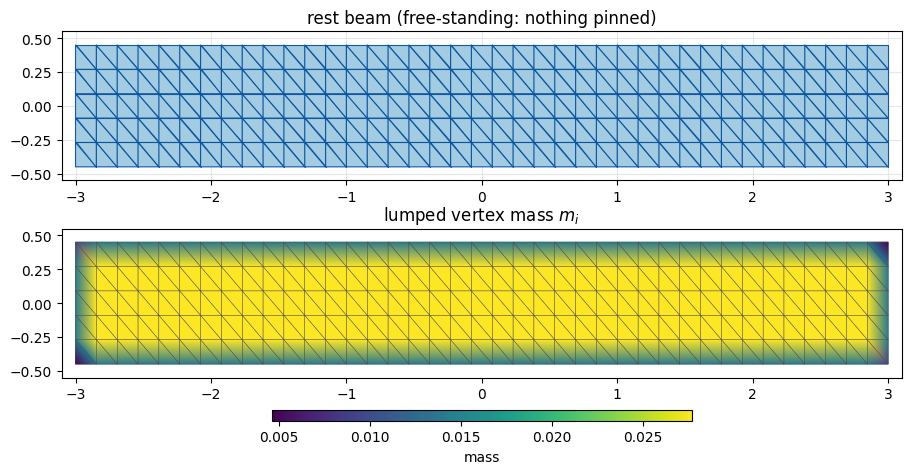

In [2]:
V, T = igl.triangulated_grid(NX, NY)                         # unit square, NX x NY vertices
X = (V - 0.5) * np.array([WIDTH, HEIGHT])                    # centered WIDTH x HEIGHT rectangle
n, dim = X.shape
x_rest = X.reshape(-1, 1)                                    # stacked rest positions

M_vertex = simkit.massmatrix(X, T, rho=RHO)                  # lumped, diagonal (n, n)
M = sp.sparse.kron(M_vertex, sp.sparse.eye(dim)).tocsc()     # one copy per DOF, (n*dim, n*dim)
print(f"beam: {n} vertices, {len(T)} triangles, {n * dim} DOFs, total mass {M_vertex.sum():.2f}")

fig, axes = plt.subplots(2, 1, figsize=(9, 4.6), layout="constrained")
utils.plot_mesh(axes[0], X, T, title="rest beam (free-standing: nothing pinned)")
field = utils.plot_scalar_field(axes[1], X, T, M_vertex.diagonal(), title="lumped vertex mass $m_i$",
                                colorbar=False)
fig.colorbar(field, ax=axes[1], orientation="horizontal", shrink=0.5, aspect=40, label="mass")
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "beam.png"),
                              copy_to=os.path.join(MEDIA_DIR, "019_beam.png"))
plt.show()

## The elastic system

`free_beam_system` is the beam's mechanical system, built from simkit: small-strain elasticity evaluated on
$F = Jx$ and weighted by triangle area. With nothing pinned it is the only term. Linear elasticity is
quadratic in $x$, so its Hessian at rest **is** the stiffness $H$ of both mode problems. It is already
positive semi-definite, so we take it exactly (`psd=False`).

In [3]:
def free_beam_system(X, T, material):
    """Elastic energy of an unpinned body, in stacked vertex positions x."""
    n, dim = X.shape
    J = simkit.deformation_jacobian(X, T)
    vol = simkit.volume(X, T)
    mu = np.full((len(T), 1), MU)
    lam = np.full((len(T), 1), LAM)

    def energy_func(x):
        E_elastic = simkit.energies.elastic_energy_x(x.reshape(n, dim), J, mu, lam, vol, material)
        E_total = E_elastic
        return E_total

    def gradient_func(x):
        g_elastic = simkit.energies.elastic_gradient_x(x.reshape(n, dim), J, mu, lam, vol, material)
        g_total = g_elastic
        return g_total

    def hessian_func(x):
        H_elastic = simkit.energies.elastic_hessian_x(x.reshape(n, dim), J, mu, lam, vol, material, psd=False)
        H_total = H_elastic
        return H_total

    return energy_func, gradient_func, hessian_func

beam_energy, beam_gradient, beam_hessian = free_beam_system(X, T, MATERIAL)
H = beam_hessian(x_rest).tocsc()                             # constant stiffness, (n*dim, n*dim)

## The compressed-mode objective

`compressed_mode_system` is the objective of one compressed mode in its displacement $u$: the elastic term
$\tfrac12 u^\top H u$ plus the sparsity term $\lambda\, m^\top |u|$, with $m$ the lumped mass of every DOF.
Away from $u_i = 0$ the sparsity gradient is $\lambda\, m \odot \operatorname{sign}(u)$ and its Hessian
vanishes. The kink at zero is what makes exact zeros optimal, and why Newton is the wrong tool:
`simkit.eigs_iccm` instead splits $u = u_+ - u_-$ with $u_\pm \ge 0$, which makes the $L_1$ term linear, and
solves a convex QP per iteration. We use these closures to check and score its modes.

In [4]:
def compressed_mode_system(H, M, l):
    """Compressed-mode objective 0.5 u^T H u + l m^T |u| in a modal displacement u."""
    m = np.asarray(M.sum(axis=1)).reshape(-1, 1)             # lumped mass of every DOF
    b0 = np.zeros((H.shape[0], 1))                           # the elastic term has no linear part

    def energy_func(u):
        E_elastic = simkit.energies.quadratic_energy(u, H, b0)
        E_sparse = l * (m.T @ np.abs(u)).item()
        E_total = E_elastic + E_sparse
        return E_total

    def gradient_func(u):
        g_elastic = simkit.energies.quadratic_gradient(u, H, b0)
        g_sparse = l * m * np.sign(u)                        # a subgradient wherever some u_i = 0
        g_total = g_elastic + g_sparse
        return g_total

    def hessian_func(u):
        H_elastic = simkit.energies.quadratic_hessian(H)
        H_sparse = sp.sparse.csc_matrix(H.shape)             # |u| is piecewise linear: no curvature
        H_total = H_elastic + H_sparse
        return H_total

    return energy_func, gradient_func, hessian_func

## Check both systems

At a random displacement $d$ (all entries nonzero, so $|u|$ is differentiable there), central finite
differences (`simkit.gradient_cfd`) of each energy should match its gradient, and the beam energy should
equal $\tfrac12 d^\top H d$, confirming that $H$ captures the whole elastic energy.

In [5]:
rng = np.random.default_rng(SEED)
d = FD_NOISE * rng.standard_normal((n * dim, 1))             # random displacement
mode_energy, mode_gradient, mode_hessian = compressed_mode_system(H, M, LAMBDAS[-1])
checks = {"free_beam_system": (beam_energy, beam_gradient, x_rest + d),
          "compressed_mode_system": (mode_energy, mode_gradient, d)}
for name, (energy_func, gradient_func, y) in checks.items():
    g = gradient_func(y)
    g_fd = simkit.gradient_cfd(lambda z: np.array(energy_func(z.reshape(-1, 1))), y.ravel(), FD_STEP)
    rel_err = np.linalg.norm(g_fd.reshape(-1, 1) - g) / np.linalg.norm(g)
    print(f"{name:23s} |g_fd - g| / |g| = {rel_err:.1e}")
print(f"E(x_rest + d) = {beam_energy(x_rest + d):.12f}")
print(f"0.5 d^T H d   = {0.5 * (d.T @ (H @ d)).item():.12f}")

free_beam_system        |g_fd - g| / |g| = 5.3e-10
compressed_mode_system  |g_fd - g| / |g| = 5.1e-10
E(x_rest + d) = 4.159243608927
0.5 d^T H d   = 4.159243608927


## Linear modal analysis: global modes

`simkit.eigs` solves $Hu = \omega^2 Mu$ for the lowest eigenpairs (what `simkit.linear_modal_analysis` does
for a unit material). The first three eigenvalues are $\approx 0$: the rigid translations and rotation in the
null space of $H$. We drop them and keep the next five, the **deformation** modes. `active_fraction`
measures locality: the share of (vertex, mode) pairs that move more than 5% of their mode's peak. For LMA
it is 1: every mode moves every vertex.

In [6]:
def mode_magnitude(B):
    """Per-vertex displacement magnitude of every mode (column) of B, shape (n, k)."""
    return np.linalg.norm(B.reshape(n, dim, -1), axis=1)

def active_fraction(B):
    """Share of (vertex, mode) pairs that move more than ACTIVE_THRESH of their mode's peak."""
    mag = mode_magnitude(B)
    return (mag > ACTIVE_THRESH * mag.max(axis=0)).mean()

omega2, B_all = simkit.eigs(H, k=N_RIGID + N_MODES, M=M)
print("eigenvalues omega^2:", np.round(omega2, 4), f" <- the first {N_RIGID} are rigid-body modes")
B_lma = B_all[:, N_RIGID:]                                   # the first N_MODES deformation modes
print(f"LMA active-vertex fraction: {active_fraction(B_lma):.2f}")

eigenvalues omega^2: [-0.     -0.      0.      0.0668  0.403   0.7292  1.2043  2.5513]  <- the first 3 are rigid-body modes
LMA active-vertex fraction: 1.00


Each mode is played as $x(t) = X + a\,\sin(2\pi t)\,u$, rescaled so every mode's largest vertex displacement
is the same on screen (`utils.animate_mode_shapes`; the gray ghost is the rest shape). Every mode is a
standing wave over the **whole** beam: the bending modes add a half-wavelength each, and mode 3 stretches
the beam along its length. This global character is what we want to break.

In [7]:
fig, anim = utils.animate_mode_shapes(
    X, T, B_lma, n_frames=N_FRAMES, amp=SCREEN_AMP, fps=FPS,
    titles=[f"mode {j + 1}   ($\\omega^2$ = {w:.3f})" for j, w in enumerate(omega2[N_RIGID:])],
    suptitle="Linear modal analysis: every mode spans the whole beam")
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "lma_modes.mp4"), fps=FPS,
                                         copy_to=os.path.join(MEDIA_DIR, "019_lma_modes.mp4"))
plt.close(fig)
utils.embed_video(video)

## Turning on the sparsity knob $\lambda$

`simkit.eigs_iccm` computes five compressed modes per $\lambda$ from the same $H$ and $M$, each from a seeded
random start. The printout confirms the constraint (the basis is $M$-orthonormal, $U^\top M U = I$, to
round-off) and shows the active fraction falling as $\lambda$ grows.

In [8]:
B_iccm = {}
for l in LAMBDAS:
    np.random.seed(SEED)                                     # eigs_iccm draws its starts from np.random
    B_iccm[l] = simkit.eigs_iccm(H, l=l, k=N_MODES, M=M, tolerance=ICCM_TOL, max_iters=ICCM_ITERS)
    gram = np.dot(B_iccm[l].T, M @ B_iccm[l])                # U^T M U
    residual = np.abs(gram - np.eye(N_MODES)).max()
    print(f"lambda = {l:>4}:  active-vertex fraction {active_fraction(B_iccm[l]):.2f},"
          f"  max |U^T M U - I| = {residual:.1e}")

lambda =  0.5:  active-vertex fraction 0.51,  max |U^T M U - I| = 1.0e-15


lambda =  2.0:  active-vertex fraction 0.31,  max |U^T M U - I| = 4.4e-16


lambda =  8.0:  active-vertex fraction 0.19,  max |U^T M U - I| = 4.4e-16


**$\lambda = 0.5$**, light pressure: each mode already lives on part of the beam (about half of it on
average), and the rest goes quiet.

In [9]:
l = LAMBDAS[0]
fig, anim = utils.animate_mode_shapes(
    X, T, B_iccm[l], n_frames=N_FRAMES, amp=SCREEN_AMP, fps=FPS,
    suptitle=f"Compressed modes, $\\lambda$ = {l}  (active fraction {active_fraction(B_iccm[l]):.2f})")
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, f"iccm_l{l}.mp4"), fps=FPS,
                                         copy_to=os.path.join(MEDIA_DIR, f"019_iccm_l{l}.mp4"))
plt.close(fig)
utils.embed_video(video)

**$\lambda = 2$**: each mode now occupies one *region* (an end, or a stretch of the middle), and the rest of
the beam is frozen.

In [10]:
l = LAMBDAS[1]
fig, anim = utils.animate_mode_shapes(
    X, T, B_iccm[l], n_frames=N_FRAMES, amp=SCREEN_AMP, fps=FPS,
    suptitle=f"Compressed modes, $\\lambda$ = {l}  (active fraction {active_fraction(B_iccm[l]):.2f})")
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, f"iccm_l{l}.mp4"), fps=FPS,
                                         copy_to=os.path.join(MEDIA_DIR, f"019_iccm_l{l}.mp4"))
plt.close(fig)
utils.embed_video(video)

**$\lambda = 8$**, strong pressure: modes collapse to compact **local** bumps. Only a small patch breathes
while the rest stays exactly at rest. Same beam, same five modes: we only changed how much spreading out costs.

In [11]:
l = LAMBDAS[2]
fig, anim = utils.animate_mode_shapes(
    X, T, B_iccm[l], n_frames=N_FRAMES, amp=SCREEN_AMP, fps=FPS,
    suptitle=f"Compressed modes, $\\lambda$ = {l}  (active fraction {active_fraction(B_iccm[l]):.2f})")
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, f"iccm_l{l}.mp4"), fps=FPS,
                                         copy_to=os.path.join(MEDIA_DIR, f"019_iccm_l{l}.mp4"))
plt.close(fig)
utils.embed_video(video)

## Seeing the support shrink directly

Each mode's per-vertex displacement magnitude on the rest beam (normalized by its peak) shows its support at a
glance: bright vertices move, black ones stay put. The top row is LMA, and each row below raises $\lambda$.
Mode order changes with $\lambda$, so a column is not one mode followed down the rows. Still, the total bright
area of a row shrinks as $\lambda$ grows: the modes become sparser.

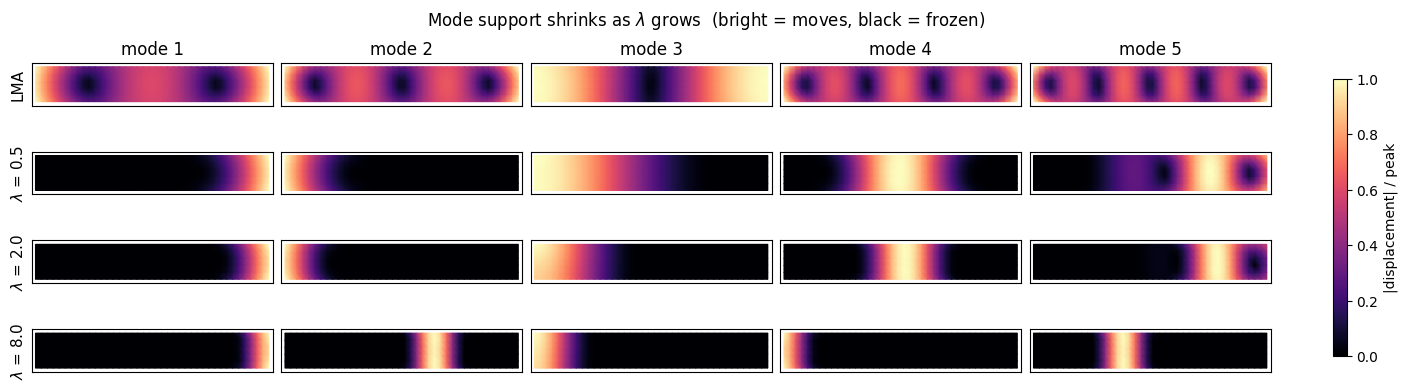

In [12]:
rows = {"LMA": B_lma, **{f"$\\lambda$ = {l}": B_iccm[l] for l in LAMBDAS}}
fig, axes = plt.subplots(len(rows), N_MODES, figsize=(14, 3.9), layout="constrained")
for r, (name, B) in enumerate(rows.items()):
    mag = mode_magnitude(B)
    for j in range(N_MODES):
        field = utils.plot_scalar_field(axes[r, j], X, T, mag[:, j] / mag[:, j].max(), cmap="magma",
                                        vmin=0, vmax=1, edges=False, colorbar=False,
                                        title=f"mode {j + 1}" if r == 0 else None)
        axes[r, j].set_xticks([])
        axes[r, j].set_yticks([])
    axes[r, 0].set_ylabel(name, fontsize=11)
fig.colorbar(field, ax=axes, shrink=0.8, label="|displacement| / peak")
fig.suptitle("Mode support shrinks as $\\lambda$ grows  (bright = moves, black = frozen)")
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "heatmaps.png"),
                              copy_to=os.path.join(MEDIA_DIR, "019_heatmaps.png"))
plt.show()

## Quantifying sparsity

The active-vertex fraction, averaged over the five modes, falls steeply with $\lambda$: LMA modes touch every
vertex, and by $\lambda = 8$ each mode moves under a fifth of the beam.

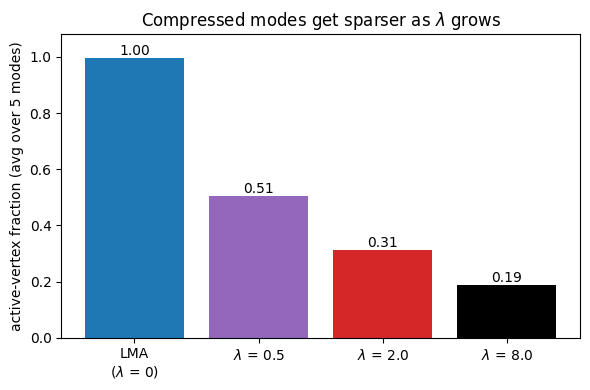

In [13]:
labels = ["LMA\n($\\lambda$ = 0)"] + [f"$\\lambda$ = {l}" for l in LAMBDAS]
fractions = [active_fraction(B_lma)] + [active_fraction(B_iccm[l]) for l in LAMBDAS]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(labels, fractions, color=["#1f77b4", "#9467bd", "#d62728", "#000000"])
for i, v in enumerate(fractions):
    ax.text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=10)
ax.set_ylim(0, 1.08)
ax.set_ylabel(f"active-vertex fraction (avg over {N_MODES} modes)")
ax.set_title("Compressed modes get sparser as $\\lambda$ grows")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "sparsity.png"),
                              copy_to=os.path.join(MEDIA_DIR, "019_sparsity.png"))
plt.show()

## Did the solver lower its objective?

Both bases are $M$-normalized, so we can score each against the compressed objective of every $\lambda$, split
into its two terms (the elastic part is `beam_energy` at $X + u$, i.e. $\tfrac12 u^\top H u$). LMA modes are
elastically cheap but pay the sparsity term on every vertex; the compressed modes roughly halve the total.
Their elastic part grows with $\lambda$ (at $\lambda = 8$ they buy locality with stiffness). At $\lambda = 0.5$
it is even below LMA's, since unlike the LMA deformation modes they are not $M$-orthogonal to the rigid
motions and can let a patch move almost rigidly.

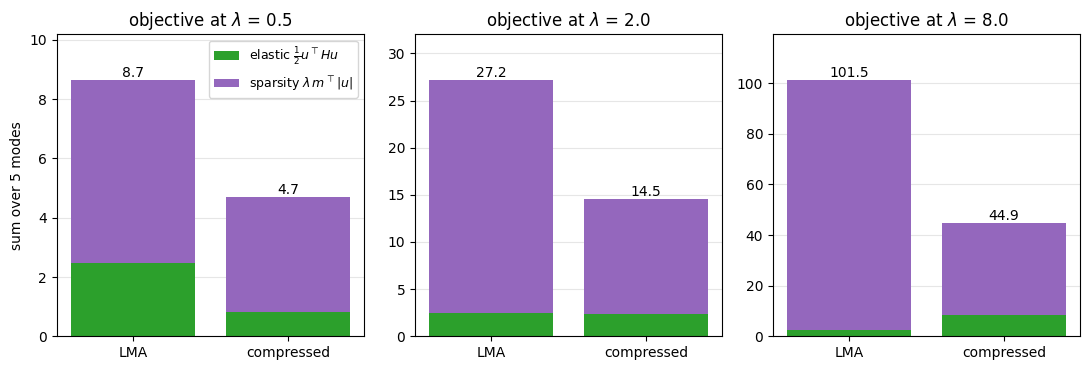

In [14]:
fig, axes = plt.subplots(1, len(LAMBDAS), figsize=(11, 3.8))
for ax, l in zip(axes, LAMBDAS):
    mode_energy, mode_gradient, mode_hessian = compressed_mode_system(H, M, l)
    for i, (name, B) in enumerate([("LMA", B_lma), ("compressed", B_iccm[l])]):
        E_elastic = sum(beam_energy(x_rest + B[:, [j]]) for j in range(N_MODES))
        E_total = sum(mode_energy(B[:, [j]]) for j in range(N_MODES))
        E_sparse = E_total - E_elastic
        ax.bar(i, E_elastic, color="#2ca02c", label="elastic $\\frac{1}{2}u^\\top Hu$" if i == 0 else None)
        ax.bar(i, E_sparse, bottom=E_elastic, color="#9467bd",
               label="sparsity $\\lambda\\, m^\\top|u|$" if i == 0 else None)
        ax.text(i, E_total, f"{E_total:.1f}", ha="center", va="bottom", fontsize=10)
    ax.set_xticks([0, 1], ["LMA", "compressed"])
    ax.set_ylim(0, 1.12 * ax.get_ylim()[1])
    ax.set_title(f"objective at $\\lambda$ = {l}")
    ax.grid(True, axis="y", color="0.9")
    ax.set_axisbelow(True)
axes[0].set_ylabel(f"sum over {N_MODES} modes")
axes[0].legend(loc="upper right", fontsize=9)
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "objective.png"),
                              copy_to=os.path.join(MEDIA_DIR, "019_objective.png"))
plt.show()

## Takeaways

* **LMA modes are global.** They diagonalize $H$ against $M$, and the low-frequency shapes span the whole body:
  great for spectral analysis, awkward for local editing.
* **An $L_1$ penalty buys locality.** Minimizing $\tfrac12 u^\top H u + \lambda\, m^\top|u|$ (mass-normalized,
  deflated) keeps a mode smooth where it lives and exactly zero everywhere else.
* **One knob.** $\lambda$ slides from global LMA ($\lambda \to 0$) to tight local bumps (large $\lambda$), with
  nothing else touched.
* **`simkit.eigs_iccm`** works for any $(H, M)$ pair, giving a local basis for part-based deformation, sparse
  control and domain-decomposed reduced simulation, where a global basis couples everything to everything.